In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [9]:
train_df = pd.read_csv('/kaggle/input/datasets/rugved2607/train-test/train.csv')
test_df = pd.read_csv('/kaggle/input/datasets/rugved2607/train-test/test.csv')
val_df = pd.read_csv('/kaggle/input/datasets/rugved2607/train-test/val.csv')

img = '/kaggle/input/datasets/organizations/nih-chest-xrays/data'

image_path_lookup = {}
for folder in os.listdir(img):
    folder_images_path = os.path.join(img, folder, 'images')
    if os.path.exists(folder_images_path):
        for img_file in os.listdir(folder_images_path):
            image_path_lookup[img_file] = os.path.join(folder_images_path, img_file)

print(f"Total images indexed: {len(image_path_lookup)}")

all_classes = ['No Finding', 'Infiltration', 'Effusion', 'Atelectasis',
               'Nodule', 'Mass', 'Pneumothorax', 'Consolidation',
               'Pleural_Thickening', 'Cardiomegaly', 'Emphysema',
               'Edema', 'Fibrosis', 'Pneumonia', 'Hernia']

Total images indexed: 112120


In [10]:
train_df['path'] = train_df['Image Index'].map(image_path_lookup)
val_df['path'] = val_df['Image Index'].map(image_path_lookup)
test_df['path'] = test_df['Image Index'].map(image_path_lookup)

In [11]:
import numpy as np

def encode_labels(label_string):
    vector = np.zeros(len(all_classes))
    
    for label in label_string.split('|'):
        if label in all_classes:
            vector[all_classes.index(label)] = 1
            
    return vector

In [12]:
train_df['target'] = train_df['Finding Labels'].apply(encode_labels)
val_df['target'] = val_df['Finding Labels'].apply(encode_labels)
test_df['target'] = test_df['Finding Labels'].apply(encode_labels)

In [13]:
import torch
from torch.utils.data import Dataset
from PIL import Image

class ChestXrayDataset(Dataset):
    
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        image = Image.open(row['path']).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        label = torch.tensor(row['target'], dtype=torch.float32)
        
        return image, label

In [14]:
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

train_dataset = ChestXrayDataset(train_df, transform)
val_dataset = ChestXrayDataset(val_df, transform)
test_dataset = ChestXrayDataset(test_df, transform)

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4
)

In [15]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32, 15])


In [16]:
import torch
import torch.nn as nn
import torchvision.models as models

model = models.densenet121(pretrained=True)

num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 15)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [16]:
from tqdm import tqdm

num_epochs = 3

for epoch in range(num_epochs):

    # ----- TRAINING -----
    model.train()
    train_loss = 0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1} Training")
    
    for images, labels in train_bar:
        
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
        train_bar.set_postfix(loss=loss.item())
    
    
    # ----- VALIDATION -----
    model.eval()
    val_loss = 0
    
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1} Validation")
    
    with torch.no_grad():
        for images, labels in val_bar:
            
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            
            val_bar.set_postfix(loss=loss.item())
    
    
    print(f"\nEpoch {epoch+1} Summary")
    print(f"Train Loss: {train_loss/len(train_loader):.4f}")
    print(f"Val Loss: {val_loss/len(val_loader):.4f}")

Epoch 1 Validation: 100%|██████████| 267/267 [01:33<00:00,  2.85it/s, loss=0.258] 



Epoch 1 Summary
Train Loss: 0.1766
Val Loss: 0.1627


Epoch 2 Validation: 100%|██████████| 267/267 [01:33<00:00,  2.85it/s, loss=0.264] 



Epoch 2 Summary
Train Loss: 0.1613
Val Loss: 0.1615


Epoch 3 Validation: 100%|██████████| 267/267 [01:24<00:00,  3.16it/s, loss=0.257] 


Epoch 3 Summary
Train Loss: 0.1564
Val Loss: 0.1590


In [17]:
from sklearn.metrics import roc_auc_score
import torch

model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in val_loader:
        
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)   # convert logits → probabilities

        all_labels.append(labels.cpu())
        all_preds.append(probs.cpu())

# convert lists to arrays
all_labels = torch.cat(all_labels).numpy()
all_preds = torch.cat(all_preds).numpy()

# compute ROC-AUC
auc_per_class = roc_auc_score(all_labels, all_preds, average=None)
mean_auc = roc_auc_score(all_labels, all_preds, average="macro")

print("Mean ROC-AUC:", mean_auc)

print("\nAUC per disease:")
for i, disease in enumerate(all_classes):
    print(f"{disease}: {auc_per_class[i]:.4f}")

Mean ROC-AUC: 0.8262549494543112

AUC per disease:
No Finding: 0.7756
Infiltration: 0.7178
Effusion: 0.9001
Atelectasis: 0.8177
Nodule: 0.7534
Mass: 0.8416
Pneumothorax: 0.8685
Consolidation: 0.8102
Pleural_Thickening: 0.8057
Cardiomegaly: 0.8901
Emphysema: 0.8835
Edema: 0.9211
Fibrosis: 0.8191
Pneumonia: 0.7425
Hernia: 0.8470


In [28]:
torch.save(model.state_dict(), "best_model.pth")

**GRAD-CAM**

In [4]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.5 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=658e432582ccf4901c6874d4be75dfc75837077b93415f970b8e6a845049a311
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [5]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [25]:
import gradio as gr
import torch
import torchvision.transforms as transforms
import numpy as np
from PIL import Image, ImageDraw
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

all_classes = ['No Finding', 'Infiltration', 'Effusion', 'Atelectasis',
               'Nodule', 'Mass', 'Pneumothorax', 'Consolidation',
               'Pleural_Thickening', 'Cardiomegaly', 'Emphysema',
               'Edema', 'Fibrosis', 'Pneumonia', 'Hernia']

inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

model.eval()
target_layer = model.features[-1]

def add_caption(img_np, disease, confidence):
    img_pil = Image.fromarray(img_np)
    new_img = Image.new('RGB', (img_pil.width, img_pil.height + 30), (255, 255, 255))
    new_img.paste(img_pil, (0, 0))
    draw = ImageDraw.Draw(new_img)
    draw.text((6, img_pil.height + 6), f"{disease} — {confidence:.1%}", fill=(30, 30, 30))
    return new_img

def predict(image):
    if image is None:
        return {}, []

    img_rgb = image.convert('RGB')
    img_resized = img_rgb.resize((224, 224))
    img_np = np.array(img_resized).astype(np.float32) / 255.0
    input_tensor = inference_transform(img_rgb).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.sigmoid(output).cpu().numpy()[0]

    results = {all_classes[i]: float(probs[i]) for i in range(15)}

    detected = [(all_classes[i], probs[i]) for i in range(15) if probs[i] >= 0.5]
    if len(detected) == 0:
        top2_idx = np.argsort(probs)[-2:][::-1]
        detected = [(all_classes[i], probs[i]) for i in top2_idx]

    gradcam_images = []
    cam = GradCAM(model=model, target_layers=[target_layer])

    for disease_name, confidence in detected:
        class_idx = all_classes.index(disease_name)
        targets = [ClassifierOutputTarget(class_idx)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
        visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
        captioned = add_caption(visualization, disease_name, confidence)
        gradcam_images.append(captioned)

    return results, gradcam_images

with gr.Blocks(title="Chest X-Ray Classifier") as demo:
    gr.Markdown("# <h1 align='center'>Chest X-Ray Disease Classifier</h1>")
    gr.Markdown("<h4 align='center'>DenseNet-121 · NIH CXR8 · 112,120 images · Mean AUC 0.8309 · 14 pathologies</h4>")

    with gr.Row():
        with gr.Column():
            image_input = gr.Image(type='pil', label="Upload Chest X-Ray")
            submit_btn = gr.Button("Analyze", variant="primary")
            gr.Markdown("⚠️ *Research use only. Not for clinical diagnosis.*")

        with gr.Column():
            label_output = gr.Label(num_top_classes=6, label="Disease Probabilities")

    gr.Markdown("### Grad-CAM Heatmaps")
    gr.Markdown("*One heatmap per detected disease. Red = high attention, blue = low attention.*")
    
    gradcam_gallery = gr.Gallery(
        label="",
        columns=3,
        rows=2,
        height=400
    )

    submit_btn.click(
        fn=predict,
        inputs=image_input,
        outputs=[label_output, gradcam_gallery]
    )

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7867
* Running on public URL: https://0ed117d44ffecde7c2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [26]:
gradio deploy

SyntaxError: invalid syntax (3470978507.py, line 1)

In [29]:
from IPython.display import FileLink
FileLink('best_model.pth')

/kaggle/working/best_model.pth

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

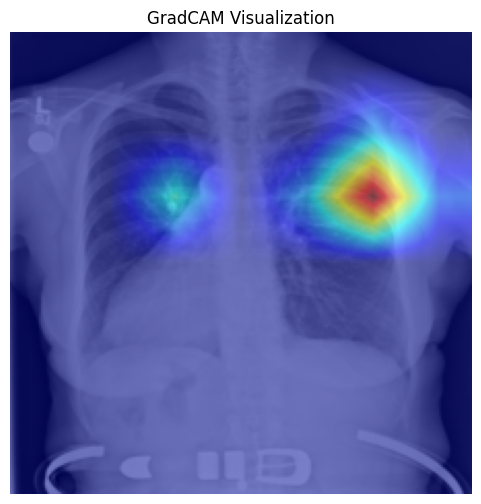

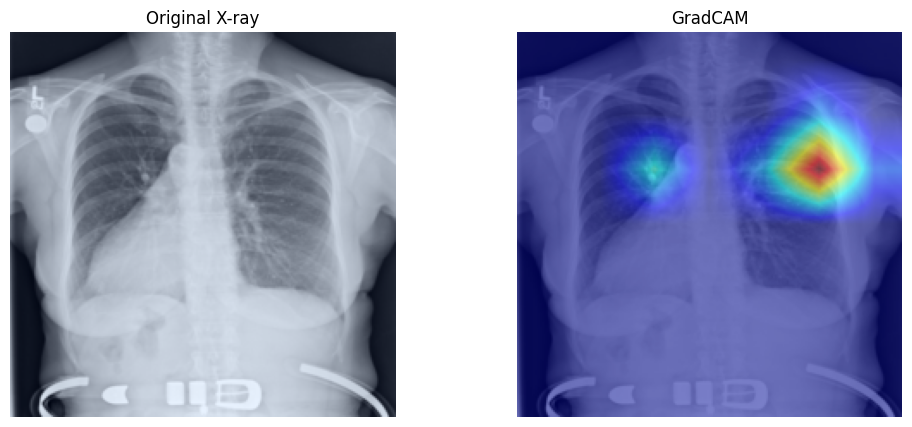

In [17]:
target_layer = model.features[-1]
image, label = val_dataset[0]

input_tensor = image.unsqueeze(0).to(device)

class_idx = all_classes.index("Effusion")

targets = [ClassifierOutputTarget(class_idx)]

cam = GradCAM(model=model, target_layers=[target_layer])

grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
grayscale_cam = grayscale_cam[0]

image_np = image.permute(1,2,0).numpy()
image_np = (image_np - image_np.min())/(image_np.max()-image_np.min())

visualization = show_cam_on_image(image_np, grayscale_cam, use_rgb=True)

plt.figure(figsize=(6,6))
plt.imshow(visualization)
plt.title("GradCAM Visualization")
plt.axis("off")

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image_np)
plt.title("Original X-ray")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("GradCAM")
plt.axis("off")

In [23]:
!pip install --upgrade gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.0/43.0 MB 46.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 4.6 MB/s eta 0:00:00
  Attempting uninstall: gradio-client
    Found existing installation: gradio_client 1.14.0
    Uninstalling gradio_client-1.14.0:
      Successfully uninstalled gradio_client-1.14.0
  Attempting uninstall: gradio
    Found existing installation: gradio 5.50.0
    Uninstalling gradio-5.50.0:
      Successfully uninstalled gradio-5.50.0
